In [84]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
import os
import fiona
from geopy.distance import geodesic

In [85]:
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
fire_data = gpd.read_file("../total_fire.geojson")

In [86]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

In [87]:
fire_data = calculer_duree(fire_data, 'date_debut', 'date_fin')
fire_data['centroid'] = fire_data.geometry.centroid
fire_data['centroid_lon'] = fire_data['centroid'].x
fire_data['centroid_lat'] = fire_data['centroid'].y
fire_data['date_debut'] = pd.to_datetime(fire_data['date_debut'], errors='coerce')
fire_data['hour'] = fire_data['date_debut'].dt.hour
fire_data['date'] = pd.to_datetime(fire_data['date'], errors='coerce')
fire_data['month'] = fire_data['date'].dt.month
fire_data['weekday'] = fire_data['date'].dt.weekday
fire_data['season'] = fire_data['month'].apply(season_encoding)
fire_data[['hour_sin', 'hour_cos']] = cyclical_encoding(fire_data['hour'], 24)
fire_data[['month_sin', 'month_cos']] = cyclical_encoding(fire_data['month'], 12)
fire_data[['weekday_sin', 'weekday_cos']] = cyclical_encoding(fire_data['weekday'], 7)
fire_data['duree_minutes'] = pd.to_timedelta(fire_data['duree']).dt.total_seconds() / 60

<ipython-input-87-36aaf5ed8f08>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_data['centroid'] = fire_data.geometry.centroid


In [88]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
print(firepoint.head())

            hex_id  scale0      NDVI      NDMI      NDBI      NDSI      NDWI  \
0  871f91d93ffffff       0  0.489482  0.027680 -0.027680 -0.526345 -0.531443   
1  871f91c58ffffff       1  0.489056  0.012780 -0.012780 -0.509756 -0.505684   
2  871f91d35ffffff       2  0.539409  0.034183 -0.034183 -0.558490 -0.569783   
3  871f91719ffffff       3  0.642989  0.106361 -0.106361 -0.551762 -0.613317   
4  871f95600ffffff       4  0.482576 -0.035056  0.035056 -0.556619 -0.523738   

  osmnx  PasDeRoute  motorway  ...       tree     grass     crops      shrub  \
0  None   98.156682       0.0  ...  19.226831  0.908858  0.012801  52.662570   
1  None   95.492169       0.0  ...  22.551891  3.323571  0.382020  13.243346   
2  None   97.275518       0.0  ...   5.257099  6.382707  5.001279  42.862625   
3  None   97.029326       0.0  ...  11.704964  5.281198  0.330075   1.701155   
4  None   96.868609       0.0  ...   7.796524  6.045501  2.121677  16.308793   

    flooded      built  bare  snow sin

In [89]:
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

fire_data = fire_data.merge(firepoint, on='hex_id', how='left')

print(fire_data.head())

            hex_id raison_sortie          date_debut            date_fin  \
0  871f91c4dffffff      NATURELS 2018-01-05 17:41:19 2018-01-05 18:45:21   
1  871f91c6effffff      NATURELS 2018-01-06 17:56:49 2018-01-06 19:37:07   
2  871f910d6ffffff      NATURELS 2018-01-12 08:43:15 2018-01-12 09:36:25   
3  871f91c9bffffff      NATURELS 2018-01-15 17:55:58 2018-01-15 18:59:14   
4  871f910e3ffffff      NATURELS 2018-01-19 22:57:16 2018-01-20 00:21:51   

   label    year       date         departement  \
0    1.0  2018.0 2018-01-05  departement-01-ain   
1    1.0  2018.0 2018-01-06  departement-01-ain   
2    1.0  2018.0 2018-01-12  departement-01-ain   
3    1.0  2018.0 2018-01-15  departement-01-ain   
4    1.0  2018.0 2018-01-19  departement-01-ain   

                                            geometry           duree  ...  \
0  POLYGON ((5.39217 46.12447, 5.39416 46.11236, ... 0 days 01:04:02  ...   
1  POLYGON ((5.32470 46.15261, 5.32670 46.14050, ... 0 days 01:40:18  ...   
2  PO

Dimensions du DataFrame :
(8569, 72)

Info sur les types de données et les valeurs manquantes :
<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 8569 entries, 0 to 8568
Data columns (total 72 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   hex_id                 8569 non-null   object         
 1   raison_sortie          8569 non-null   object         
 2   date_debut             8569 non-null   datetime64[ns] 
 3   date_fin               8569 non-null   datetime64[ns] 
 4   label                  8569 non-null   float64        
 5   year                   8569 non-null   float64        
 6   date                   8569 non-null   datetime64[ns] 
 7   departement            8569 non-null   object         
 8   geometry               8569 non-null   geometry       
 9   duree                  8569 non-null   timedelta64[ns]
 10  centroid               8569 non-null   geometry       
 11  cent

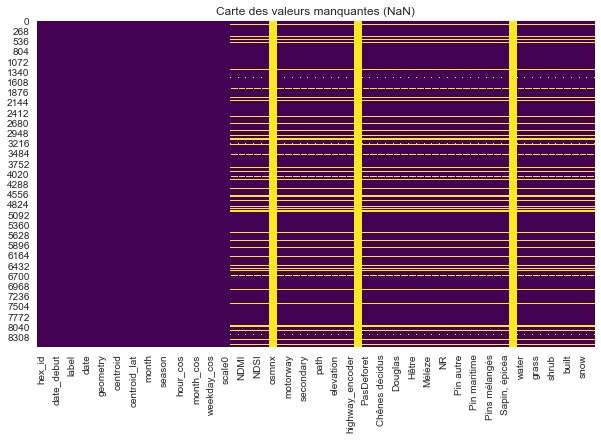


Nombre de valeurs manquantes (NaN) par colonne :
hex_id             0
raison_sortie      0
date_debut         0
date_fin           0
label              0
                ... 
flooded          944
built            944
bare             944
snow             944
sinister         944
Length: 72, dtype: int64


In [90]:
print("Dimensions du DataFrame :")
print(fire_data.shape)

print("\nInfo sur les types de données et les valeurs manquantes :")
print(fire_data.info())

plt.figure(figsize=(10, 6))
sns.heatmap(fire_data.isnull(), cbar=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (NaN)")
plt.show()

print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(fire_data.isnull().sum())

In [91]:
interventions = fire_data.drop(columns=['scale0', 'hour', 'raison_sortie', 'centroid', 'month', 'year', 'weekday'])

In [92]:
import pandas as pd

def custom_agg(series):
    """Si toutes les valeurs sont identiques, retourne cette valeur, sinon met NaN"""
    unique_values = series.dropna().unique()
    return unique_values[0] if len(unique_values) == 1 else None

# Agréger les données
interventions_mean = interventions.groupby('geometry').agg(lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else custom_agg(x)).reset_index()

# Afficher un aperçu
print(interventions_mean.head())

                                            geometry           hex_id  \
0  POLYGON ((1.89553215036948 48.49626115680366, ...  871fb6ae4ffffff   
1  POLYGON ((1.835130551782781 48.4934375228796, ...  871fb6a18ffffff   
2  POLYGON ((1.827812206963572 48.530682097488665...  871fb6a03ffffff   
3  POLYGON ((1.839268039843263 48.55000785725174,...  871fb6a01ffffff   
4  POLYGON ((1.858037207943677 48.53209419698605,...  871fb6a0effffff   

           date_debut            date_fin  label       date  \
0                 NaT                 NaT    1.0        NaT   
1 2020-07-01 15:11:31 2020-07-01 16:06:12    1.0 2020-07-01   
2                 NaT                 NaT    1.0        NaT   
3                 NaT                 NaT    1.0        NaT   
4                 NaT                 NaT    1.0        NaT   

               departement           duree  centroid_lon  centroid_lat  ...  \
0  departement-78-yvelines             NaT      1.897955     48.483847  ...   
1  departement-78-yvelin

In [100]:
nan_percentage = interventions_mean.isna().mean() * 100

cols_to_keep = nan_percentage[nan_percentage <= 50].index

interventions_clean = interventions_mean[cols_to_keep]

print("\nDimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :")
print(interventions_clean.shape)

print("\nColonnes restantes après nettoyage :")
print(interventions_clean.columns)


Dimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :
(1913, 58)

Colonnes restantes après nettoyage :
Index(['geometry', 'hex_id', 'label', 'departement', 'centroid_lon',
       'centroid_lat', 'season', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos', 'weekday_sin', 'weekday_cos', 'duree_minutes', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister'],
      dtype='object')


In [101]:
interventions_clean = interventions_clean.dropna()

print("\nVérification des NaN après suppression des lignes dans fire_data_drop :")
print(interventions_clean.isna().sum())

print("\nDimensions du DataFrame fire_data_drop après suppression des NaN :")
print(interventions_clean.shape)


Vérification des NaN après suppression des lignes dans fire_data_drop :
geometry                 0
hex_id                   0
label                    0
departement              0
centroid_lon             0
centroid_lat             0
season                   0
hour_sin                 0
hour_cos                 0
month_sin                0
month_cos                0
weekday_sin              0
weekday_cos              0
duree_minutes            0
NDVI                     0
NDMI                     0
NDBI                     0
NDSI                     0
NDWI                     0
PasDeRoute               0
motorway                 0
primary                  0
secondary                0
tertiary                 0
path                     0
population               0
elevation                0
foret_encoder            0
highway_encoder          0
PasDeforet               0
Châtaignier              0
Chênes décidus           0
Conifères                0
Douglas                  0
Feuillus 

In [95]:
interventions = interventions.drop(columns=['sinister'])


In [97]:
"""X = interventions_mean.drop(columns=['duree_minutes', 'hex_id', 'date', 'departement', 'geometry', 'duree', 'date_debut', 'date_fin', 'geometry', 'label'])"""
X = interventions_mean.drop(columns=['hex_id', 'duree_minutes', 'geometry', 'geometry', 'label'])
y = interventions_mean['duree_minutes']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importance des features')
plt.show()

print(importance_df.head(20))

TypeError: float() argument must be a string or a number, not 'NaTType'

In [102]:
print(X.dtypes)  # Vérifie les types de données
print(X.isna().sum())  # Vérifie les valeurs NaN ou NaT

date_debut      datetime64[ns]
date_fin        datetime64[ns]
date            datetime64[ns]
departement             object
duree          timedelta64[ns]
                    ...       
flooded                float64
built                  float64
bare                   float64
snow                   float64
sinister               float64
Length: 61, dtype: object
date_debut     1317
date_fin       1317
date           1313
departement       0
duree          1317
               ... 
flooded         207
built           207
bare            207
snow            207
sinister        207
Length: 61, dtype: int64


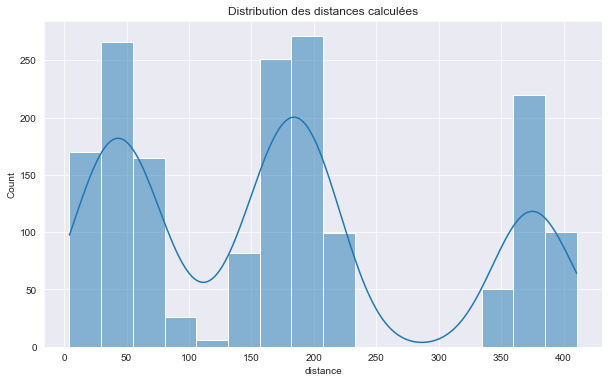

In [59]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

interventions_mean['distance'] = interventions_mean.apply(
    lambda row: haversine(row['centroid_lon'], row['centroid_lat'], 6.5, 47.5), axis=1
)

plt.figure(figsize=(10, 6))
sns.histplot(interventions_mean['distance'], kde=True)
plt.title('Distribution des distances calculées')
plt.show()

In [61]:
feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 15 des features les plus importantes :")
print(importance_df.head(15))

important_features = importance_df['Feature'].head(15).tolist()

if 'centroid_lon' not in important_features:
    important_features.append('centroid_lon')
if 'centroid_lat' not in important_features:
    important_features.append('centroid_lat')
if 'hour_cos' not in important_features:
    important_features.append('hour_cos')
if 'hour_sin' not in important_features:
    important_features.append('hour_sin')

X_selected = X[important_features]

print("\nFeatures utilisées pour l'entraînement du modèle :")
print(X_selected.columns)

Top 15 des features les plus importantes :
          Feature  Importance
47          shrub    0.108670
0    centroid_lon    0.098895
4        hour_cos    0.082153
9            NDVI    0.076043
21      elevation    0.071808
16        primary    0.066926
13           NDWI    0.061491
49          built    0.057292
44           tree    0.056254
46          crops    0.040048
40  Pins mélangés    0.039785
15       motorway    0.032547
2          season    0.025424
24     PasDeforet    0.024710
11           NDBI    0.023674

Features utilisées pour l'entraînement du modèle :
Index(['shrub', 'centroid_lon', 'hour_cos', 'NDVI', 'elevation', 'primary',
       'NDWI', 'built', 'tree', 'crops', 'Pins mélangés', 'motorway', 'season',
       'PasDeforet', 'NDBI', 'centroid_lat', 'hour_sin'],
      dtype='object')


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nÉvaluation du modèle :")
print(f"Mean Squared Error (MSE) : {mse}")
print(f"Mean Absolute Error (MAE) : {mae}")
print(f"R² (coefficient de détermination) : {r2}")
print(f"Root Mean Squared Error (RMSE) : {rmse}")


Évaluation du modèle :
Mean Squared Error (MSE) : 706560.5257921626
Mean Absolute Error (MAE) : 181.58239326491605
R² (coefficient de détermination) : -0.40827336431006445
Root Mean Squared Error (RMSE) : 840.571547098855
